In [1]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

2026-04-30 11:59:51.866456: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777564792.378374  232563 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777564792.491781  232563 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777564794.080345  232563 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777564794.080383  232563 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777564794.080385  232563 computation_placer.cc:177] computation placer alr

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Standard library imports
import os                          # For interacting with the operating system
from pathlib import Path           # For handling file system paths
import warnings                    # For managing warnings
import import_ipynb                # For importing Jupyter notebooks as modules

# Third-party library imports
import matplotlib.pyplot as plt    # For plotting graphs and images
import numpy as np                 # For numerical operations
from sklearn.model_selection import train_test_split  # For splitting datasets into training and testing sets


# Custom utility functions
from utils import (
    load_images_and_masks,         # Function to load images and masks
    view_data,                     # Function to visualize data
    preprocess_images_and_masks,   # Function to preprocess images and masks
    remap_mask_classes,            # Function to remap mask classes
    save_datasets,                 # Function to save presplit datasets
    load_datasets,                 # Function to load presplit datasets
    save_associated_files,         # Function to save associated files
    custom_warnings,               # Function to format custom warnings
)

# Custom U-Net related functions
from unet import (
    unet_model,                    # Function to create the U-Net model
    test_unet,                     # Function to test the U-Net model
    plot_losses,                   # Function to plot training losses
    save_predicted_masks,          # Function to save predicted masks
    iou_metric,                    # Function to calculate Intersection over Union
    dice_coeff,                    # Function to calculate Dice coefficient
)

# Optional line to suppress TensorFlow warnings
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

# TensorFlow and Keras imports
from tensorflow.keras import callbacks, optimizers  # For handling callbacks and optimizers in Keras
import tensorflow as tf                             # TensorFlow library

# Force the warnings library to use the custom warnings format
warnings.formatwarning = custom_warnings

In [3]:
# Force all seed values to be the same. This should only be done when testing.
PRODUCTION = False  # Flag to indicate whether the environment is production or not

# Seed value for reproducibility
seed_value = 42

# If not in production, set the seed values to ensure reproducibility
if not PRODUCTION:
    np.random.seed(seed_value) # Set the seed for NumPy's random number generator
    tf.random.set_seed(seed_value) # Set the seed for TensorFlow's random number generator
    os.environ["PYTHONHASHSEED"] = str(seed_value) # Set the seed for Python's built-in hash function    

In [4]:
# Set the necessary directories. These should be relative to the working directory
images_dir = "Datasets/Pala_Mesa_Roads_Rails/images"  # Directory for images
masks_dir = "Datasets/Pala_Mesa_Roads_Rails/labels"  # Directory for masks
model_dir = "models"  # Directory for saving the model
model_name = "trained_UNet_merged.keras"  # Model file name
model_path = Path(f"{model_dir}/{model_name}")  # Full path to the model file as a Path object

In [5]:
# Load the images and masks
images, masks, missing_masks, names_map = load_images_and_masks(
    images_dir,          # Directory containing the images
    masks_dir,           # Directory containing the masks
    file_ext="tif",      # File extension of the images and masks
    max_count=1000,      # Maximum number of images and masks to load
    trim_names=True      # Whether to trim the names of the files
)

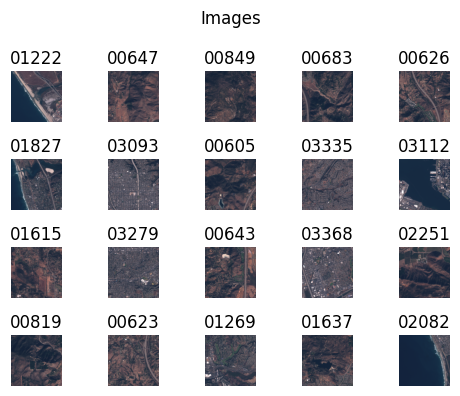

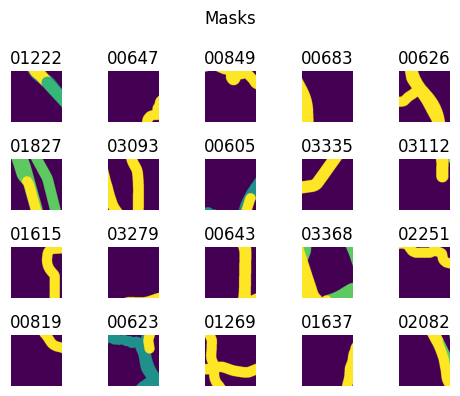

In [6]:
# View images and masks
view_data(
    images=images,       # List of images to view
    masks=masks,         # List of masks to view
    max_plots=20,        # Maximum number of plots to display
    max_cols=5,          # Maximum number of columns in the plot grid
    randomize=True,      # Whether to randomize the order of the images and masks
    colors=True          # Whether to display the masks in color
)

In [7]:
# Optional remapping of classes
REMAP_CLASSES = False  # Flag to indicate whether to remap classes
class_mapping = {0: 0, 1: 1, 2: 1, 3: 1}  # Dictionary mapping old classes to new classes
if REMAP_CLASSES:
    masks, num_classes = remap_mask_classes(masks, class_mapping)  # Remap the classes in the masks
    view_data(masks=masks, max_plots=20, max_cols=5, randomize=False, colors=True)  # View the remapped masks

In [8]:
# Preprocess the data for the U-Net
# Assign default values to the number of classes
num_classes = 4  # Default number of classes. It is okay if this is incorrect. The preprocess_images_and_masks function will let you know. 

# Preprocess images and masks for the U-Net model
preprocessed_images, preprocessed_masks, threshold, image_names, num_classes = (
    preprocess_images_and_masks(
        images,                   # List of images to preprocess
        masks,                    # List of masks to preprocess
        num_classes=num_classes,  # Number of classes
        threshold=0.5             # Threshold value for binarizing masks
    )
)

I0000 00:00:1777564853.399655  232563 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 79191 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-80GB, pci bus id: 0000:0f:00.0, compute capability: 8.0
2026-04-30 12:00:53.405824: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 786432000 exceeds 10% of free system memory.
2026-04-30 12:02:20.201993: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 786432000 exceeds 10% of free system memory.
You must have at least the the number of possible classes, in this case 5, with the following classes: [0, 1, 2, 3, 4]
2026-04-30 12:02:29.795974: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 1310720000 exceeds 10% of free system memory.


Preprocessed data information:
Number of images: 1000.
Shape of images dataset: (1000, 256, 256, 3).
Images type: float32.
Number of masks: 1000.
Shape of masks dataset: (1000, 256, 256, 5).
Masks type: float32.
Number of classes: 5.


In [9]:
# this is used to calculate distance from roads
from scipy.ndimage import distance_transform_edt


# VEGETATION (NDVI)
# NDVI tells us how "green" or vegetated an area is plants reflect near 
# infrared light and absorb red light so we use that difference to estimate vegetation
# used chatgpt to help w this section

def compute_ndvi(images):
    ndvi_maps = []  # we will store one NDVI map per image

    for img in images:
        # get red and near-infrared channels
        red = img[:, :, 0].astype(np.float32)
        nir = img[:, :, 1].astype(np.float32)

        # NDVI formula
        ndvi = (nir - red) / (nir + red + 1e-6)

        # create empty classification map
        veg_class = np.zeros_like(ndvi)

        # convert NDVI values into categories
        veg_class[ndvi < 0.2] = 0   # low vegetation
        veg_class[(ndvi >= 0.2) & (ndvi < 0.5)] = 1  # medium
        veg_class[ndvi >= 0.5] = 2  # dense vegetation

        ndvi_maps.append(veg_class)

    return np.array(ndvi_maps)

In [10]:
# ROAD RISK

def compute_road_risk(masks):
    road_risk_maps = []

    for mask in masks:
        # find where roads are
        # (we assume roads = class 1... may need to check)
        road_mask = (np.argmax(mask, axis=-1) == 1).astype(np.uint8)

        # compute distance from roads
        distance = distance_transform_edt(1 - road_mask)

        # normalize (scale from 0 to 1)
        distance = distance / np.max(distance)

        # create empty risk map
        risk = np.zeros_like(distance)


        # assign risk levels based on distance
        risk[distance < 0.1] = 3   # very close = high risk
        risk[(distance >= 0.1) & (distance < 0.3)] = 2
        risk[(distance >= 0.3) & (distance < 0.6)] = 1
        risk[distance >= 0.6] = 0  # far away = low risk

        road_risk_maps.append(risk)

    return np.array(road_risk_maps)

In [11]:
# new labels

# vegetation labels from NDVI
vegetation_maps = compute_ndvi(preprocessed_images)

# road risk labels from masks
road_risk_maps = compute_road_risk(preprocessed_masks)

# convert CNA labels --> binary fire (fire vs no fire)
# original masks have multiple classes (background, low, high, extreme etc)
# we turn everything that is NOT background into fire
binary_masks = (np.argmax(preprocessed_masks, axis=-1) > 0).astype(np.uint8)

# expand dims so shape becomes (N, 256, 256, 1) 
binary_masks = np.expand_dims(binary_masks, axis=-1)

# check shapes
print("Vegetation maps:", vegetation_maps.shape)
print("Road risk maps:", road_risk_maps.shape)
print("Binary burn masks:", binary_masks.shape) # should be (1000, 256, 256, 1)

Vegetation maps: (1000, 256, 256)
Road risk maps: (1000, 256, 256)
Binary burn masks: (1000, 256, 256, 1)


In [12]:
# split data 

(
    images_train,
    images_test_and_val,
    burn_train,
    burn_test_and_val,
    veg_train,
    veg_test_and_val,
    road_train,
    road_test_and_val,
    names_train,
    names_test_and_val,
) = train_test_split(
    preprocessed_images,
    binary_masks,
    vegetation_maps,
    road_risk_maps,
    image_names,
    test_size=0.2,
    random_state=42,
)

# split again into validation + test
(
    images_validation,
    images_test,
    burn_validation,
    burn_test,
    veg_validation,
    veg_test,
    road_validation,
    road_test,
    names_validation,
    names_test,
) = train_test_split(
    images_test_and_val,
    burn_test_and_val,
    veg_test_and_val,
    road_test_and_val,
    names_test_and_val,
    test_size=0.5,
    random_state=42,
)

In [13]:
#  model 

from tensorflow.keras import layers, Model

def multi_output_unet(input_shape=(256,256,3)):

    inputs = layers.Input(shape=input_shape)

    # encoder (learn features)
    c1 = layers.Conv2D(64, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(64, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(128, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(128, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D()(c2)

    # bottleneck 
    b = layers.Conv2D(256, 3, activation='relu', padding='same')(p2)
    b = layers.Conv2D(256, 3, activation='relu', padding='same')(b)

    # decoder (rebuild image)
    u1 = layers.UpSampling2D()(b)
    u1 = layers.concatenate([u1, c2])
    c3 = layers.Conv2D(128, 3, activation='relu', padding='same')(u1)

    u2 = layers.UpSampling2D()(c3)
    u2 = layers.concatenate([u2, c1])
    c4 = layers.Conv2D(64, 3, activation='relu', padding='same')(u2)

    # outputs 
    burn_output = layers.Conv2D(1, 1, activation="sigmoid", name="burn_output")(c4)
    veg_output = layers.Conv2D(3, 1, activation="softmax", name="veg_output")(c4)
    road_output = layers.Conv2D(4, 1, activation="softmax", name="road_output")(c4)

    return Model(inputs=inputs, outputs=[burn_output, veg_output, road_output])

In [14]:
# build model
model = multi_output_unet()

# tell model how to learn
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss={
        "burn_output": "binary_crossentropy",
        "veg_output": "sparse_categorical_crossentropy",
        "road_output": "sparse_categorical_crossentropy",
    },
    metrics={
        "burn_output": ["accuracy"],
        "veg_output": ["accuracy"],
        "road_output": ["accuracy"],
    }
)

# print model structure
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 128, 128,  │          0 │ conv2d_5[0][0]    │
│ (UpSampling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128, 128,  │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 384)              │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 128, 128,  │    442,496 │ concatenate[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 256, 256,  │          0 │ conv2d_6[0][0]    │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 256, 256,  │          0 │ up_sampling2d_1[… │
│ (Concatenate)       │ 192)              │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 256, 256,  │    110,656 │ concatenate_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ burn_output         │ (None, 256, 256,  │         65 │ conv2d_7[0][0]    │
│ (Conv2D)            │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ veg_output (Conv2D) │ (None, 256, 256,  │        195 │ conv2d_7[0][0]  

 Total params: 1,699,080 (6.48 MB)

 Trainable params: 1,699,080 (6.48 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# training

model_fit = model.fit(
    images_train,
    {
        "burn_output": burn_train,
        "veg_output": veg_train,
        "road_output": road_train,
    },
    batch_size=8,
    epochs=25,
    validation_data=(
        images_validation,
        {
            "burn_output": burn_validation,
            "veg_output": veg_validation,
            "road_output": road_validation,
        }
    ),
    verbose=1
)

2026-04-30 12:02:59.033990: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 629145600 exceeds 10% of free system memory.
2026-04-30 12:03:04.527931: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 629145600 exceeds 10% of free system memory.


Epoch 1/25


I0000 00:00:1777564987.744143  235782 service.cc:152] XLA service 0x1554300040a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777564987.744178  235782 service.cc:160]   StreamExecutor device (0): NVIDIA A100-SXM4-80GB, Compute Capability 8.0
2026-04-30 12:03:08.000366: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1777564988.567417  235782 cuda_dnn.cc:529] Loaded cuDNN version 90300


  5/100 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - burn_output_accuracy: 0.7817 - burn_output_loss: 0.6840 - loss: 3.1011 - road_output_accuracy: 0.1066 - road_output_loss: 1.3885 - veg_output_accuracy: 0.9373 - veg_output_loss: 1.0286

I0000 00:00:1777564999.668519  235782 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 99/100 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - burn_output_accuracy: 0.7787 - burn_output_loss: 0.6103 - loss: 2.4421 - road_output_accuracy: 0.3194 - road_output_loss: 1.3319 - veg_output_accuracy: 0.9108 - veg_output_loss: 0.4999

2026-04-30 12:03:23.403906: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
2026-04-30 12:03:23.405031: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy_1/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
2026-04-30 12:03:25.707738: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
2026-04-30 12:03:25.708464: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy_1/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert


100/100 ━━━━━━━━━━━━━━━━━━━━ 23s 88ms/step - burn_output_accuracy: 0.7824 - burn_output_loss: 0.5844 - loss: 2.2110 - road_output_accuracy: 0.3773 - road_output_loss: 1.2939 - veg_output_accuracy: 0.8988 - veg_output_loss: 0.3327 - val_burn_output_accuracy: 0.7792 - val_burn_output_loss: 0.5729 - val_loss: 2.0455 - val_road_output_accuracy: 0.3925 - val_road_output_loss: 1.2997 - val_veg_output_accuracy: 0.9126 - val_veg_output_loss: 0.1760
Epoch 2/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - burn_output_accuracy: 0.7824 - burn_output_loss: 0.5429 - loss: 1.9008 - road_output_accuracy: 0.4172 - road_output_loss: 1.2495 - veg_output_accuracy: 0.9506 - veg_output_loss: 0.1084 - val_burn_output_accuracy: 0.7792 - val_burn_output_loss: 0.5326 - val_loss: 1.8551 - val_road_output_accuracy: 0.4355 - val_road_output_loss: 1.2637 - val_veg_output_accuracy: 0.9784 - val_veg_output_loss: 0.0660
Epoch 3/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - burn_output_accuracy: 0.7824 - burn_output_l

In [16]:
#predictions

preds = model.predict(images_test)

burn_preds = preds[0]
veg_preds = preds[1]
road_preds = preds[2]

4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 230ms/step


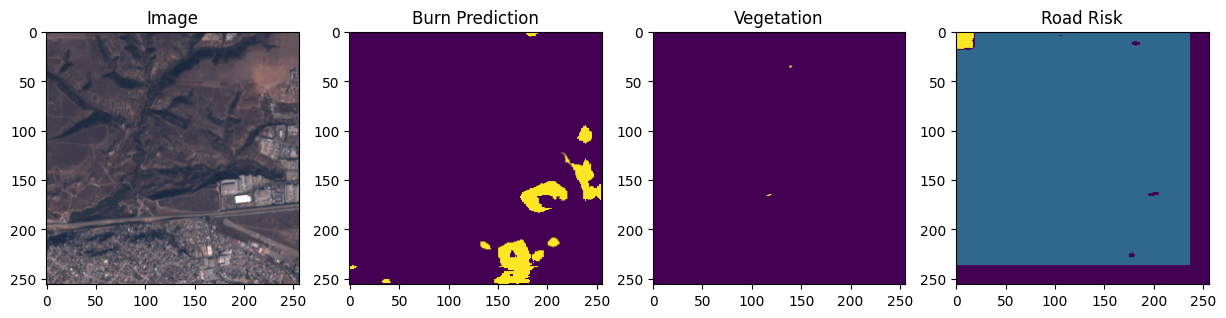

In [17]:
# visualizations

def show_results(idx):
    plt.figure(figsize=(15,5))

    plt.subplot(1,4,1)
    plt.title("Image")
    plt.imshow(images_test[idx][:,:,:3])

    plt.subplot(1,4,2)
    plt.title("Burn Prediction")
    plt.imshow((burn_preds[idx] > 0.5).astype(int))

    plt.subplot(1,4,3)
    plt.title("Vegetation")
    plt.imshow(np.argmax(veg_preds[idx], axis=-1))

    plt.subplot(1,4,4)
    plt.title("Road Risk")
    plt.imshow(np.argmax(road_preds[idx], axis=-1))

    plt.show()

show_results(0)